# 4. Rispondere alle domande
Trasforma le seguenti richiesti in formule per estrarre infromazioni dal dataframe
- Mostrami le vendite maggiori di 10

- Mostrami i dati del 2018

- Mostrami le vendite maggiori di 13 e l'anno è il 2018

- Mostrami tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018

- Mostrami i dati dove le vendite divise per 3 sono maggiori di 3

- Mostrami i dipendenti i cui nomi sono alfabeticamente dopo la J



#### LEGGENDA
- **df[df["colonna"] > x]** –> Filtro per valori maggiori di x.

- **df[df["colonna"] == x]** –> Filtro per uguaglianza.

- **df[(cond1) & (cond2)]** –> Filtro con AND.

- **df[~((cond1) & (cond2))]** –> Filtro con NOT (tutto tranne).

- **df[(df["colonna"] / 3) > x]** –> Filtro con operazione aritmetica sulla colonna.

- **df[df["colonna"] > "lettera"]** –> Filtro alfabetico su stringhe.

In [8]:
# Carico il dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sales = pd.DataFrame(
    data={
        "employee": [
            "Katrina",
            "Guanyu",
            "Jan",
            "Roman",
            "Jacqueline",
            "Paola",
            "Esperanza",
            "Alaina",
            "Egweyn",
        ],
        "sales": [14, 17, 6, 12, 8, 3, 7, 15, 5],
        "year": [2018, 2019, 2020, 2018, 2020, 2019, 2019, 2020, 2020],
    }
)
sales


# 1. Vendite maggiori di 10
print("1. Le righe con vendite maggiori di 10 sono:")
print(sales[sales["sales"] > 10].to_string(index=False), "\n")


# 2. Dati del 2018
print("2. I dati del 2018 sono:")
print(sales[sales["year"] == 2018].to_string(index=False), "\n")


# 3. Vendite maggiori di 13 e l'anno è il 2018
print("3. Le vendite maggiori di 13 nel 2018 sono:")
print(sales[(sales["sales"] > 13) & (sales["year"] == 2018)].to_string(index=False), "\n")


# 4. Mostro tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018
print("4. Tutto tranne (vendite > 13 e anno 2018):")
print(sales[~((sales["sales"] > 13) & (sales["year"] == 2018))].to_string(index=False), "\n")


# 5. Dati dove le vendite divise per 3 sono maggiori di 3
print("5. Vendite / 3 > 3 (cioè vendite > 9):")
print(sales[(sales["sales"] / 3) > 3].to_string(index=False), "\n")


# 6. Dipendenti i cui nomi sono alfabeticamente dopo la J
print("6. Dipendenti con nome alfabeticamente dopo 'J':")
print(sales[sales["employee"] > "J"].to_string(index=False))

1. Le righe con vendite maggiori di 10 sono:
employee  sales  year
 Katrina     14  2018
  Guanyu     17  2019
   Roman     12  2018
  Alaina     15  2020 

2. I dati del 2018 sono:
employee  sales  year
 Katrina     14  2018
   Roman     12  2018 

3. Le vendite maggiori di 13 nel 2018 sono:
employee  sales  year
 Katrina     14  2018 

4. Tutto tranne (vendite > 13 e anno 2018):
  employee  sales  year
    Guanyu     17  2019
       Jan      6  2020
     Roman     12  2018
Jacqueline      8  2020
     Paola      3  2019
 Esperanza      7  2019
    Alaina     15  2020
    Egweyn      5  2020 

5. Vendite / 3 > 3 (cioè vendite > 9):
employee  sales  year
 Katrina     14  2018
  Guanyu     17  2019
   Roman     12  2018
  Alaina     15  2020 

6. Dipendenti con nome alfabeticamente dopo 'J':
  employee  sales  year
   Katrina     14  2018
       Jan      6  2020
     Roman     12  2018
Jacqueline      8  2020
     Paola      3  2019


# 5. Analisi di un dataset di video giochi
1. Quanti videogiochi sono stati pubblicati
2. Quali sono i generi più popolari? Mostralo con un bar plot
3. Plotta l'evoluzione del numero di giochi pubblicati nel tempo
4. Prova a riprodurre questo plot 

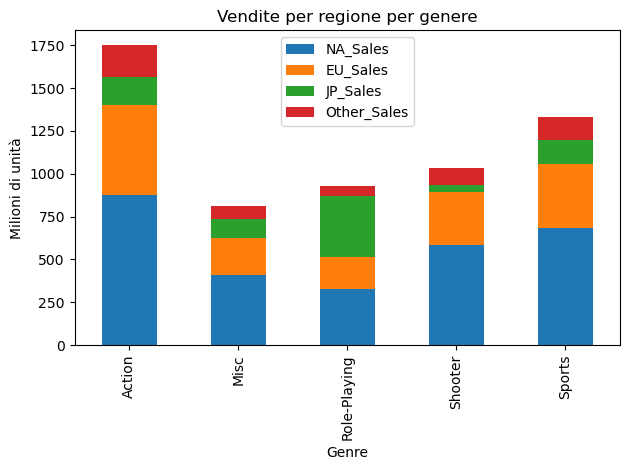


## 1. CELLA DEI CALCOLI

##### LEGGENDA
- **df.shape[0]** –> Numero di righe (videogiochi pubblicati).

- **df["Genre"].value_counts()** –> Frequenza di ciascun genere.

- **sns.countplot(y="Genre", data=df, order=...)** –> Grafico a barre orizzontali delle frequenze.

- **df.groupby("Year").size().reset_index(name="conteggio")** –> Conta i giochi per anno.

- **plt.plot(anni, conteggi, marker="o")** –> Grafico a linee dell’evoluzione temporale.

- **df[df["Genre"].isin(lista)]** –> Filtra i generi desiderati.

- **.groupby("Genre")[["NA_Sales", ...]].sum()** –> Somma le vendite per genere e regione.

- **.plot(kind="bar", stacked=True)** –> Grafico a barre impilate.

- **plt.legend(loc="upper center", bbox_to_anchor=(0.5, 0.99))** –> Legenda centrata in alto.

In [1]:
# Import dei pacchetti
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset
url = 'https://zenodo.org/record/5898311/files/vgsales.csv'
df = pd.read_csv(url)

# 1. Numero totale di videogiochi pubblicati
num_giochi = df.shape[0]

# 2. Generi più popolari (frequenza)
frequenza_generi = df["Genre"]. value_counts()

# 3. Evoluzione del numero di giochi pubblicati nel tempo
giochi_per_anno = df.groupby("Year").size().reset_index(name="conteggio")
giochi_per_anno = giochi_per_anno.sort_values("Year")
anni = giochi_per_anno["Year"].values
conteggi = giochi_per_anno["conteggio"].values

# 4. Preparazione dati per il plot richiesto
generi_scelti = ["Action", "Misc", "Role-Playing", "Shooter", "Sports"]
vendite_filtrate = df[df["Genre"].isin(generi_scelti)].groupby("Genre")[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum()
ordine_originale = ["Action", "Misc", "Role-Playing", "Shooter", "Sports"]
vendite_filtrate = vendite_filtrate.loc[ordine_originale]


# Printo tutto
print(f"1. Numero totale di videogiochi pubblicati: {num_giochi}\n")
print("2. Generi più popolari (frequenza):")
for genere, count in frequenza_generi.head(10).items():
    print(f"   {genere}: {count}")
print("\n3. Evoluzione nel tempo – prime 10 righe (anno, conteggio):")
print(giochi_per_anno.head(10).to_string(index=False))
print("\n4. Somma delle vendite per genere e regione (milioni di unità):")
print(vendite_filtrate.to_string())



1. Numero totale di videogiochi pubblicati: 16598

2. Generi più popolari (frequenza):
   Action: 3316
   Sports: 2346
   Misc: 1739
   Role-Playing: 1488
   Shooter: 1310
   Adventure: 1286
   Racing: 1249
   Platform: 886
   Simulation: 867
   Fighting: 848

3. Evoluzione nel tempo – prime 10 righe (anno, conteggio):
  Year  conteggio
1980.0          9
1981.0         46
1982.0         36
1983.0         17
1984.0         14
1985.0         14
1986.0         21
1987.0         16
1988.0         15
1989.0         17

4. Somma delle vendite per genere e regione (milioni di unità):
              NA_Sales  EU_Sales  JP_Sales  Other_Sales
Genre                                                  
Action          877.83    525.00    159.95       187.38
Misc            410.24    215.98    107.76        75.32
Role-Playing    327.28    188.06    352.31        59.61
Shooter         582.60    313.27     38.28       102.69
Sports          683.35    376.85    135.37       134.97


## 2. CELLA DEI GRAFICI

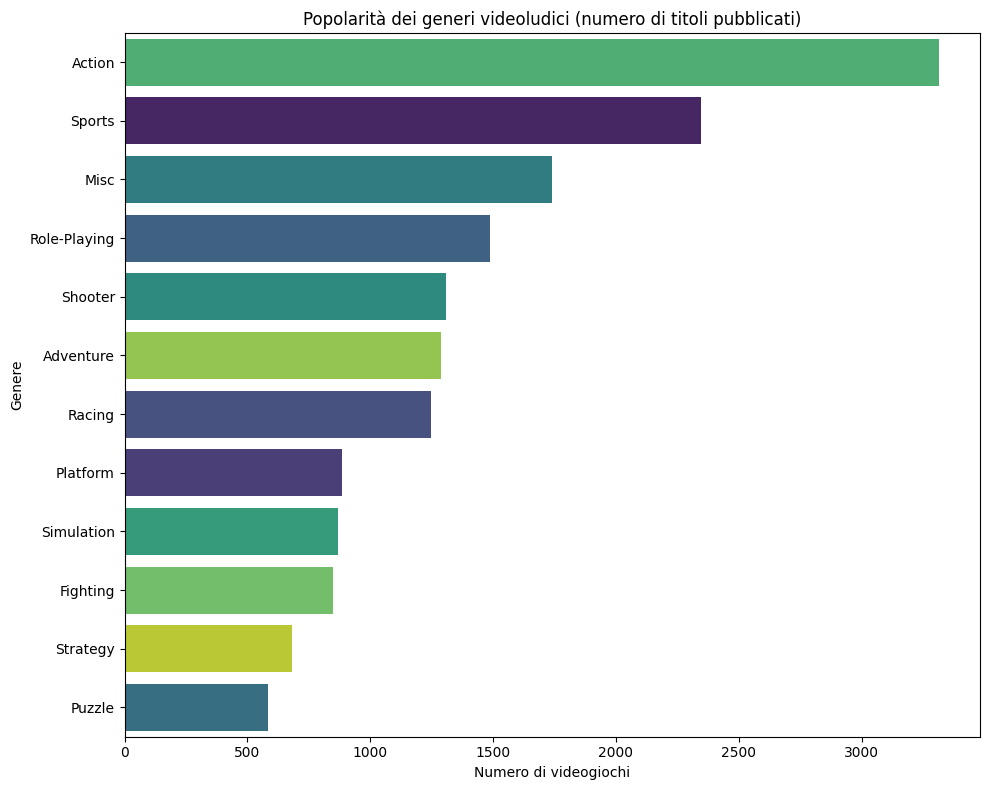

In [ ]:
# Grafico 1 – Generi più popolari (bar plot orizzontale)

plt.figure(figsize=(10, 8))
sns.countplot(data=df, y="Genre", 
              order=frequenza_generi.index, 
              hue="Genre", 
              palette="viridis", 
              legend=False)
plt.title("Popolarità dei generi videoludici (numero di titoli pubblicati)")
plt.xlabel("Numero di videogiochi")
plt.ylabel("Genere")
plt.tight_layout()
plt.show()

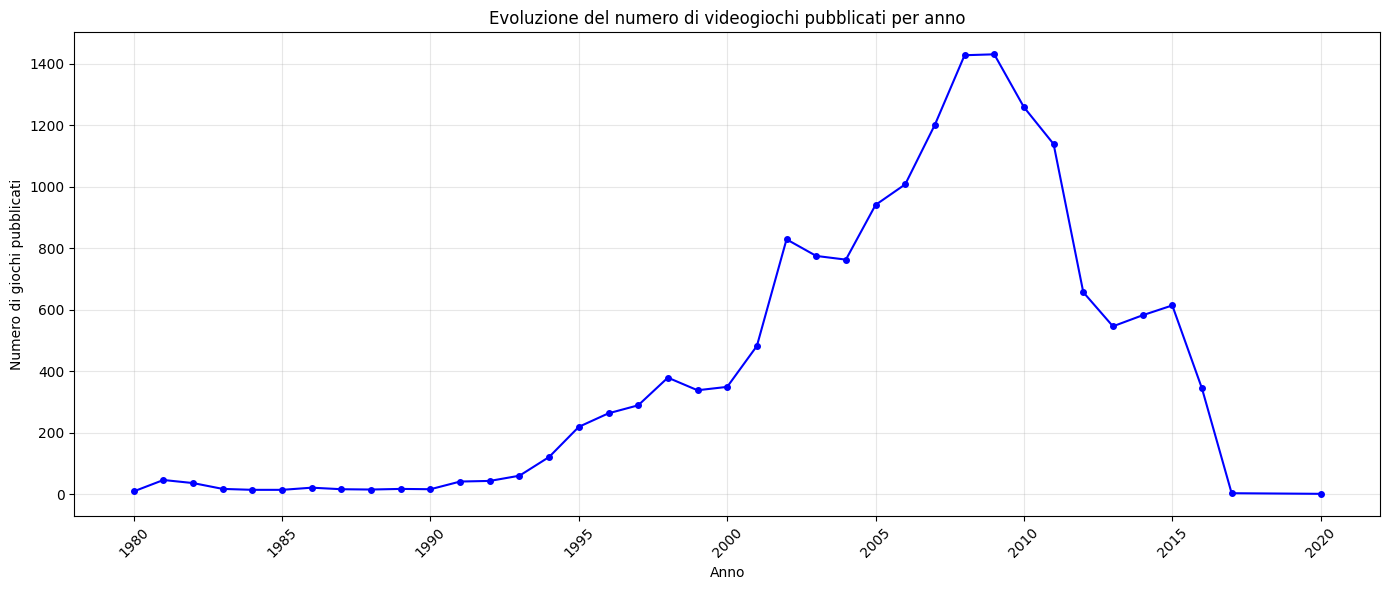

In [3]:
# Grafico 2 – Evoluzione del numero di giochi pubblicati nel tempo (line plot)

plt.figure(figsize=(14, 6))
plt.plot(anni, conteggi, marker="o", linestyle="-", color="b", markersize=4)
plt.title("Evoluzione del numero di videogiochi pubblicati per anno")
plt.xlabel("Anno")
plt.ylabel("Numero di giochi pubblicati")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

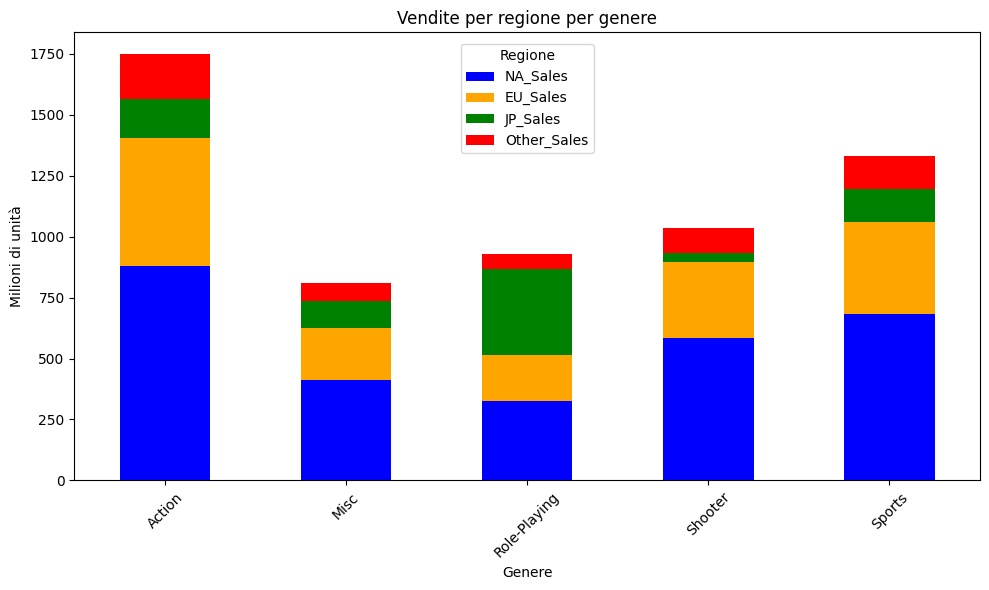

In [4]:
# Grafico 3 – Riproduzione del plot richiesto 

vendite_filtrate.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["blue", "orange", "green", "red"]
)
plt.title("Vendite per regione per genere")
plt.xlabel("Genere")
plt.ylabel("Milioni di unità")
plt.xticks(rotation=45)
plt.legend(title="Regione", loc="upper center", bbox_to_anchor=(0.5, 0.99))
plt.tight_layout()
plt.show()